### Monthly ER comparison across all –HP extensions for each year.

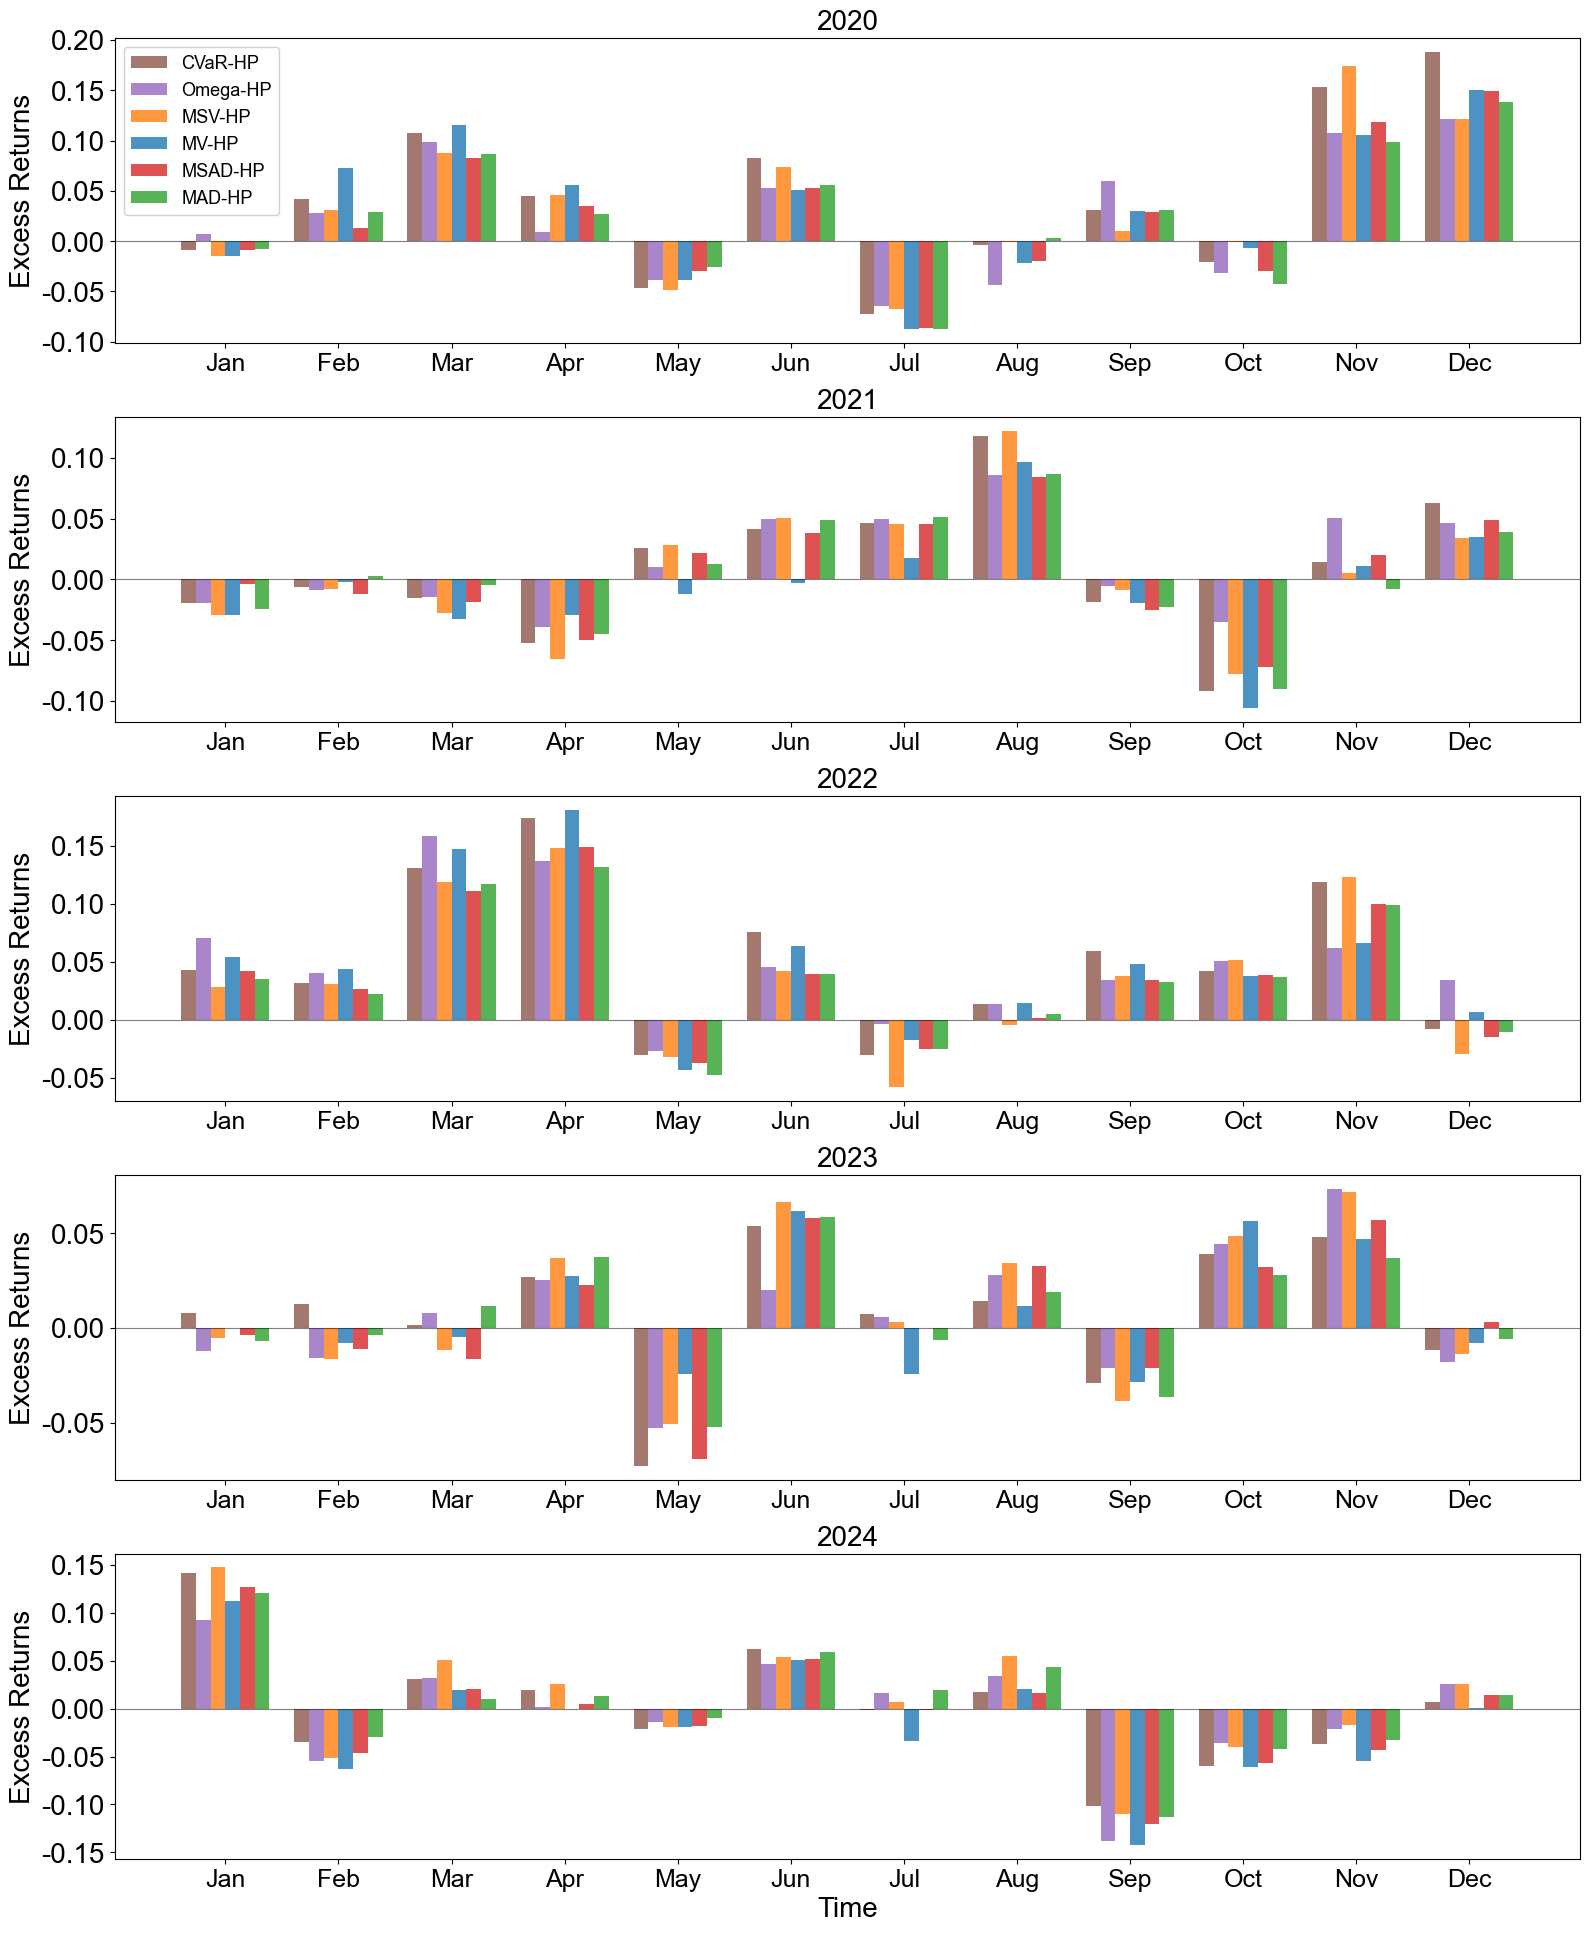

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.unicode_minus'] = False

def plot_monthly_returns_bar_charts():
    """
    Plot monthly returns bar charts for HP models only
    """
    df = pd.read_csv('Monthly_Excess_Returns.csv')

    df['year_month'] = pd.to_datetime(df['year_month'])
    df['year'] = df['year_month'].dt.year
    df['month'] = df['year_month'].dt.month

    model_names = ['CVaR-HP', 'Omega-HP', 'MSV-HP', 'MV-HP', 'MSAD-HP', 'MAD-HP']
    existing_models = [model for model in model_names if f'{model}_monthly_excess' in df.columns]
    model_names = existing_models
    years = sorted(df['year'].unique())

    model_colors = {
        'MV-HP': '#1f77b4',
        'MSV-HP': '#ff7f0e',
        'MAD-HP': '#2ca02c',
        'MSAD-HP': '#d62728',
        'Omega-HP': '#9467bd',
        'CVaR-HP': '#8c564b'
    }

    n_years = len(years)
    fig, axes = plt.subplots(n_years, 1, figsize=(16, 4 * n_years))
    
    if n_years == 1:
        axes = [axes]
    
    # Month names
    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

    n_models = len(model_names)
    width = 0.13 
    
    # Draw subplot for each year
    for i, year in enumerate(years):
        ax = axes[i]
        year_data = df[df['year'] == year].copy()
        year_data = year_data.sort_values('month')
        
        # Set bar positions
        x = np.arange(12)  # 12 months

        for j, model_name in enumerate(model_names):
            col_name = f'{model_name}_monthly_excess'
            monthly_returns = np.zeros(12)
            for _, row in year_data.iterrows():
                month_idx = int(row['month']) - 1  # Convert to 0-11 index
                if col_name in row and not pd.isna(row[col_name]):
                    monthly_returns[month_idx] = row[col_name]
            
            # Calculate offset to center 6 bars
            offset = (j - 2.5) * width  # Center align 6 bars
            
            # Draw bars without black edges
            bars = ax.bar(x + offset, monthly_returns, width, 
                         label=model_name, color=model_colors[model_name], 
                         alpha=0.8, edgecolor='none')

        if i == len(years) - 1:
            ax.set_xlabel('Time', fontsize=20)

        ax.set_ylabel('Excess Returns', fontsize=20)
        ax.set_title(f'{year}', fontsize=20)

        ax.set_xticks(x)
        ax.set_xticklabels(month_names, fontsize=18)
        ax.yaxis.set_major_locator(MultipleLocator(0.05))
        ax.tick_params(axis='y', labelsize=20)
        ax.grid(False)
        ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)
        if i == 0:
            ax.legend(loc='upper left', fontsize=13, framealpha=0.9)

    plt.tight_layout()
    plt.subplots_adjust(top=0.95)
    plt.savefig('Monthly_Returns_HP_Models_EN.png', dpi=300, bbox_inches='tight')
    plt.show()

if __name__ == "__main__":
    plot_monthly_returns_bar_charts()

### Boxplot distribution of monthly ER for all –HP extensions.

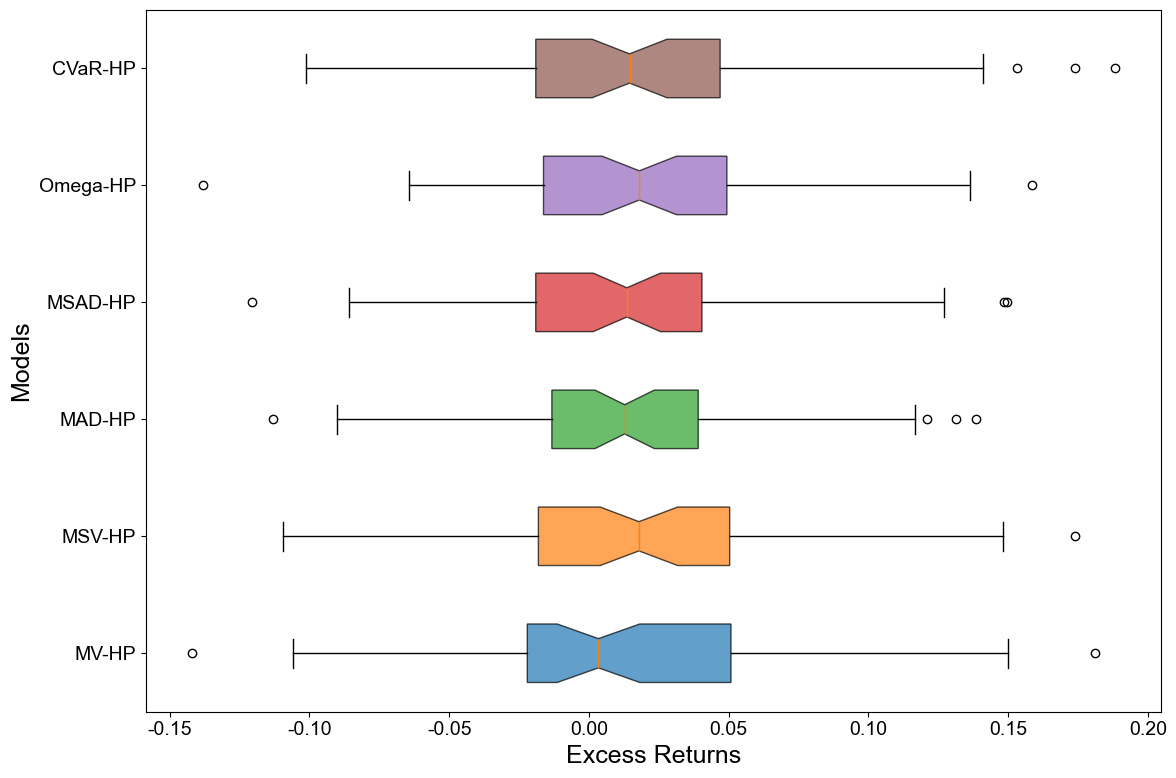

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.size'] = 14 
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14

def create_boxplot():

    df = pd.read_csv('Monthly_Excess_Returns.csv')
    model_mapping = {
        'MV-HP': 'MV-HP_monthly_excess',
        'MSV-HP': 'MSV-HP_monthly_excess', 
        'MAD-HP': 'MAD-HP_monthly_excess',
        'MSAD-HP': 'MSAD-HP_monthly_excess',
        'Omega-HP': 'Omega-HP_monthly_excess',
        'CVaR-HP': 'CVaR-HP_monthly_excess'
    }

    model_colors = {
        'MV-HP': '#1f77b4',
        'MSV-HP': '#ff7f0e',
        'MAD-HP': '#2ca02c',
        'MSAD-HP': '#d62728',
        'Omega-HP': '#9467bd',
        'CVaR-HP': '#8c564b'
    }

    model_data = {}
    model_names = ['MV-HP', 'MSV-HP', 'MAD-HP', 'MSAD-HP', 'Omega-HP', 'CVaR-HP']
    
    for model_name in model_names:
        col_name = model_mapping[model_name]
        if col_name in df.columns:
            model_data[model_name] = df[col_name].dropna().values

    valid_models = [name for name in model_names if name in model_data]
    valid_colors = [model_colors[name] for name in valid_models]

    plt.figure(figsize=(12, 8))
    
    box_data = [model_data[name] for name in valid_models]
    box_labels = valid_models

    bp = plt.boxplot(box_data, labels=box_labels, patch_artist=True, notch=True, vert=False)

    for patch, color in zip(bp['boxes'], valid_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    plt.xlabel('Excess Returns', fontsize=18)
    plt.ylabel('Models', fontsize=18)

    plt.grid(False)

    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    
    plt.tight_layout()
    plt.savefig('Monthly_BoxPlot_Horizontal_EN.png', dpi=300, bbox_inches='tight')
    plt.show()

    return True

if __name__ == "__main__":
    success = create_boxplot()

### Friedman and Wilcoxon signed-rank tests to assess differences among the proposed models. 

In [2]:
import pandas as pd
from scipy.stats import wilcoxon, friedmanchisquare
import warnings
warnings.filterwarnings('ignore')

def load_and_prepare_data():
    """加载和准备数据"""
    df = pd.read_csv('Monthly_Excess_Returns.csv')
    model_columns = [col for col in df.columns if col.endswith('-HP_monthly_excess')]
    model_names = [col.replace('_monthly_excess', '') for col in model_columns]
    df_clean = df[['year_month'] + model_columns].dropna()     
    return df_clean, model_names, model_columns

def friedman_test(df, model_names, model_columns):
    """进行Friedman检验"""
    print("\n" + "="*80)
    print("Friedman检验 (多个相关样本的非参数检验)")
    print("="*80)
    
    # 准备完整配对数据
    complete_data = df[model_columns].dropna()
    n_complete = len(complete_data)
    # 进行Friedman检验
    statistic, p_value = friedmanchisquare(*[complete_data[col] for col in model_columns])
        
    print(f"样本数 (n): {n_complete}")
    print(f"模型数 (k): {len(model_columns)}")
    print(f"自由度: {len(model_columns) - 1}")
    print(f"Friedman统计量: {statistic:.4f}")
    print(f"P值: {p_value:.8f}")
        
    if p_value < 0.05:
        print(f"结论: 拒绝原假设 (p < 0.05)，至少有一个模型的分布显著不同")
    else:
        print(f"结论: 接受原假设 (p ≥ 0.05)，所有模型的分布无显著差异")

def wilcoxon_signed_rank_tests(df, model_names, model_columns):
    """进行所有两两配对的Wilcoxon符号秩检验"""
    print("\n" + "="*80)
    print("Wilcoxon符号秩检验 (配对样本)")
    print("="*80)
    
    results = []
    for i in range(len(model_names)):
        for j in range(i+1, len(model_names)):
            model1, model2 = model_names[i], model_names[j]
            
            # 使用配对数据
            paired_data = df[[model_columns[i], model_columns[j]]].dropna()
            # 进行Wilcoxon符号秩检验
            statistic, p_value = wilcoxon(paired_data.iloc[:, 0], 
                                        paired_data.iloc[:, 1], 
                                        alternative='two-sided')
            results.append({
                'Model1': model1,
                'Model2': model2,
                'N_pairs': len(paired_data),
                'Statistic': statistic,
                'P_Value': p_value
            })

    results_df = pd.DataFrame(results)

    display_df = results_df.copy()
    display_df['模型对比'] = display_df['Model1'] + ' vs ' + display_df['Model2']
    display_df['配对数'] = display_df['N_pairs']
    display_df['W统计量'] = display_df['Statistic']
    display_df['P值'] = display_df['P_Value']
    display_cols = ['模型对比', '配对数', 'W统计量', 'P值']
    print(
        display_df[display_cols].to_string(
            index=False,
            formatters={
                '模型对比': '{:<13}'.format,
                '配对数': '{:>7}'.format,
                'W统计量': '{:>16.2f}'.format,
                'P值': '{:>18.4f}'.format
            },
            justify='center'
        )
    )
    
    return results

def main():
    """主函数"""
    # 加载数据
    df, model_names, model_columns = load_and_prepare_data()
    
    # 首先进行Friedman检验
    friedman_test(df, model_names, model_columns)
    
    # 进行Wilcoxon符号秩检验
    wilcoxon_signed_rank_tests(df, model_names, model_columns)

if __name__ == "__main__":
    main()


Friedman检验 (多个相关样本的非参数检验)
样本数 (n): 60
模型数 (k): 6
自由度: 5
Friedman统计量: 13.4095
P值: 0.01982889
结论: 拒绝原假设 (p < 0.05)，至少有一个模型的分布显著不同

Wilcoxon符号秩检验 (配对样本)
        模型对比          配对数         W统计量               P值        
    MV-HP vs MSV-HP      60           736.00             0.1876
    MV-HP vs MAD-HP      60           882.00             0.8081
   MV-HP vs MSAD-HP      60           865.00             0.7128
  MV-HP vs Omega-HP      60           688.00             0.0947
   MV-HP vs CVaR-HP      60           549.00             0.0071
   MSV-HP vs MAD-HP      60           710.00             0.1313
  MSV-HP vs MSAD-HP      60           618.00             0.0288
 MSV-HP vs Omega-HP      60           913.00             0.9883
  MSV-HP vs CVaR-HP      60           800.00             0.3972
  MAD-HP vs MSAD-HP      60           858.00             0.6748
 MAD-HP vs Omega-HP      60           722.00             0.1554
  MAD-HP vs CVaR-HP      60           532.00             0.0048
MSAD-HP vs Omega-